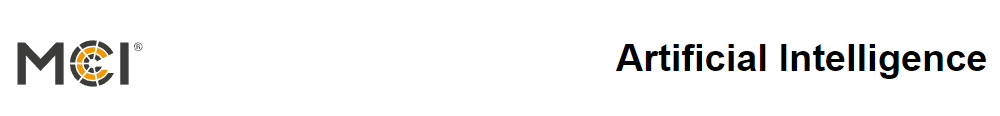

---

# 02 b Object Tracking in Football

As you can see Yolo can easily be used for object tracking. Optical Flow can be used to idetify motion. There are some limitations to the algorithms and we want to find out where they are.

In [1]:
# Import all packages needed in this notebook.
import numpy as np
import cv2 as cv
from PIL import Image
from matplotlib import pyplot as plt
import os
import glob
from scipy import signal
import shutil
from ultralytics import YOLO

# 1. Problem Statement

In Football we have passing machines in training centers like the footbonaut. See [text](https://www.youtube.com/watch?v=6-y-sDEIMb8) if you do not know what the footbonaut is. The major drawback of the footbonaut is, that it is staitionary and the access to it is highly limited to professional clubs. Meanwhile there are also mobile versions of such passing machines, like [text](https://www.youtube.com/watch?v=MNOg9L-MP0w). 

The Performance of an athlete can be measures in various ways. Mobile Passing machines meanwhile try to get some information due to video analysis. Videos with a specific number of frames and a specific frame rate are recorded every time a pass is released by the machine. The video captures the athlete receiving a pass, processing it and releasing it again with a shot or another pass. 

To somehow evaluate the performance of athletes for each time the machine releases a pass we have to retrieve relevant information from the video. Object tracking, Motion Analysis, etc. can help to do that. 

# 2. First Approach for Solution

It is quite easy to apply Yolo to the videos, as we have done this already.

In [2]:
path_Video = '../Data/Test_Videos/Football_Performance_Metric.avi'

In [3]:
# YOLO TRACKING
def yolo_Track(video_path, inter_Frame=5):
    # Load YOLO model with persistence in tracking enabled   
    model = YOLO("yolov8n.pt")
    
    cap = cv.VideoCapture(video_path)
    no_Frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    print( 'Total number of frames is' , no_Frames )
    
    while(1):
        ret, frame = cap.read()
        if not ret:
            print('No frames grabbed!')
            break
        
        # Process frame with YOLOv8 model
        results = model(frame)

        # Get annotated frame for visualisation
        frame_ = results[0].plot()
        
        # Display the frame with detected objects
        cv.imshow('Result YOLO frame', frame_)

        # Handle keypress for quitting the display window                
        k = cv.waitKey(30) & 0xff # Press 'ESC' to exit
        if k == 27:
            break
    
    # Cleanup: release video capture and destroy windows
    cap.release()
    cv.destroyAllWindows()

yolo_Track(video_path=path_Video)

Total number of frames is 209

0: 512x640 1 person, 30.4ms
Speed: 18.6ms preprocess, 30.4ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 20.1ms
Speed: 1.6ms preprocess, 20.1ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 19.0ms
Speed: 1.0ms preprocess, 19.0ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 19.0ms
Speed: 1.0ms preprocess, 19.0ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 19.6ms
Speed: 1.0ms preprocess, 19.6ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 20.1ms
Speed: 1.0ms preprocess, 20.1ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 20.6ms
Speed: 1.2ms preprocess, 20.6ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 19.0ms
Speed: 0.8ms preprocess, 19.0ms inference, 0.4ms postproce

The function shows how the object detection works in each frame of the video. For further analysis this is not suitable. We need to further develop the function to get the objects and their bounding boxes, IDs, etc.

In [4]:
# Extended YOLO tracking function to return a list of detected objects with IDs and bounding boxes
def yolo_Track_Extended(video_path):
    # Load YOLO model with tracking enabled
    model = YOLO("yolov8n.pt")
    
    cap = cv.VideoCapture(video_path)
    no_Frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    print('Total number of frames is', no_Frames)
    
    tracked_objects = []  # List to store tracked objects
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print('No frames grabbed!')
            break
        
        frame_count += 1
        
        # Process frame with YOLOv8 tracking
        results = model.track(frame, persist=True)
        
        if results[0].boxes is not None:
            for box in results[0].boxes:
                obj_id = int(box.id.item()) if box.id is not None else None
                bbox = box.xyxy[0].tolist()  # [x1, y1, x2, y2]
                cls = int(box.cls.item())
                conf = box.conf.item()
                
                tracked_objects.append({
                    'frame': frame_count,
                    'id': obj_id,
                    'class': cls,
                    'bbox': bbox,
                    'confidence': conf
                })
        
        # Optional: Display the frame (comment out if not needed)
        frame_ = results[0].plot()
        cv.imshow('Result YOLO frame', frame_)
        
        k = cv.waitKey(30) & 0xff
        if k == 27:
            break
    
    cap.release()
    cv.destroyAllWindows()
    
    return tracked_objects

# Call the extended function
tracked_data = yolo_Track_Extended(video_path=path_Video)

Total number of frames is 209

0: 512x640 1 person, 18.1ms
Speed: 0.7ms preprocess, 18.1ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 19.2ms
Speed: 1.0ms preprocess, 19.2ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 25.4ms
Speed: 1.6ms preprocess, 25.4ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 19.0ms
Speed: 0.7ms preprocess, 19.0ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 18.1ms
Speed: 0.6ms preprocess, 18.1ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 18.1ms
Speed: 1.1ms preprocess, 18.1ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 18.2ms
Speed: 0.6ms preprocess, 18.2ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 17.9ms
Speed: 1.0ms preprocess, 17.9ms inference, 0.4ms postproces

Now we can see that the video has some problems to be solved. Let's try to state the good things and tha bad things here:

Good:
* The athletes is detected quite well (high confidence, only a few missing frames)

Bad:
* The ball is detected not well in parts of the video (occlusion)
* During the video some objects are identified that are not there

Lets see the list ob objects in each frame and do some further analysis on it.

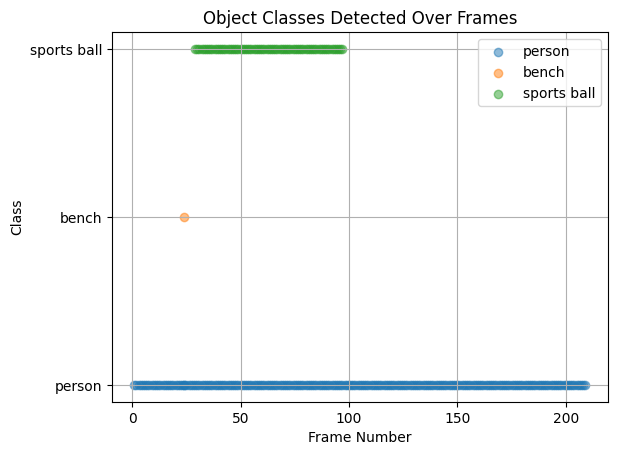

In [5]:
def plot_classes_over_frames(tracked_data):
    # Plot the object classes over the frame number
    frames = [d['frame'] for d in tracked_data]
    classes = [d['class'] for d in tracked_data]

    # Define class names based on YOLOv8 COCO dataset
    class_names = {
        0: 'person',
        13: 'bench',
        32: 'sports ball'
    }

    # Distinguish between different classes by plotting each class with a different color
    unique_classes = sorted(set(classes))
    colors = plt.cm.tab10.colors  # Use a colormap for distinct colors

    for i, cls in enumerate(unique_classes):
        cls_frames = [f for f, c in zip(frames, classes) if c == cls]
        plt.scatter(cls_frames, [i] * len(cls_frames), color=colors[i % len(colors)], label=class_names.get(cls, f'Class {cls}'), alpha=0.5)

    plt.yticks(range(len(unique_classes)), [class_names.get(cls, f'Class {cls}') for cls in unique_classes])
    plt.legend()
    plt.xlabel('Frame Number')
    plt.ylabel('Class')
    plt.title('Object Classes Detected Over Frames')
    plt.grid(True)
    plt.show()

plot_classes_over_frames(tracked_data)

In a first analysis we can see, that a bench is identified. Well, that is not right, but we can take care of it.

In [6]:
# Extended YOLO tracking function to return a list of detected objects with IDs and bounding boxes, filtered to only 'person' and 'sports ball'
def yolo_Track_Extended(video_path):
    # Load YOLO model with tracking enabled
    model = YOLO("yolov8n.pt")
    
    cap = cv.VideoCapture(video_path)
    no_Frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    print('Total number of frames is', no_Frames)
    
    tracked_objects = []  # List to store tracked objects
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print('No frames grabbed!')
            break
        
        frame_count += 1
        
        # Process frame with YOLOv8 tracking, only for classes 0 (person) and 32 (sports ball)
        results = model.track(frame, classes=[0, 32], persist=True)
        
        if results[0].boxes is not None:
            for box in results[0].boxes:
                obj_id = int(box.id.item()) if box.id is not None else None
                bbox = box.xyxy[0].tolist()  # [x1, y1, x2, y2]
                cls = int(box.cls.item())
                conf = box.conf.item()
                
                tracked_objects.append({
                    'frame': frame_count,
                    'id': obj_id,
                    'class': cls,
                    'bbox': bbox,
                    'confidence': conf
                })
        
        # Optional: Display the frame (comment out if not needed)
        frame_ = results[0].plot()
        cv.imshow('Result YOLO frame', frame_)
        
        k = cv.waitKey(30) & 0xff
        if k == 27:
            break
    
    cap.release()
    cv.destroyAllWindows()
    
    return tracked_objects

# Call the extended function
tracked_data = yolo_Track_Extended(video_path=path_Video)

Total number of frames is 209

0: 512x640 1 person, 26.2ms
Speed: 0.6ms preprocess, 26.2ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 19.0ms
Speed: 1.1ms preprocess, 19.0ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 21.3ms
Speed: 1.0ms preprocess, 21.3ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 19.6ms
Speed: 0.8ms preprocess, 19.6ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 17.8ms
Speed: 0.8ms preprocess, 17.8ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 21.4ms
Speed: 0.8ms preprocess, 21.4ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 17.0ms
Speed: 0.8ms preprocess, 17.0ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 21.7ms
Speed: 0.7ms preprocess, 21.7ms inference, 0.4ms postproces

Let's do the analysis again to check wheather the bench is still there.

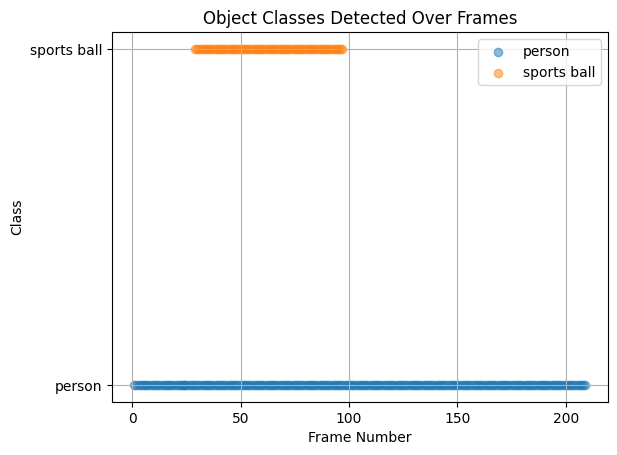

In [7]:
plot_classes_over_frames(tracked_data)

Now the bench is not identified again. Therefore, we can update our good and bad list:

Good:
* The athletes is detected quite well (high confidence, only a few missing frames)
* Only athletes and balls are identified

Bad:
* The ball is detected not well in parts of the video (occlusion)


Lets see how many balls are identified in each frame and how does the ID of the balls change over time.

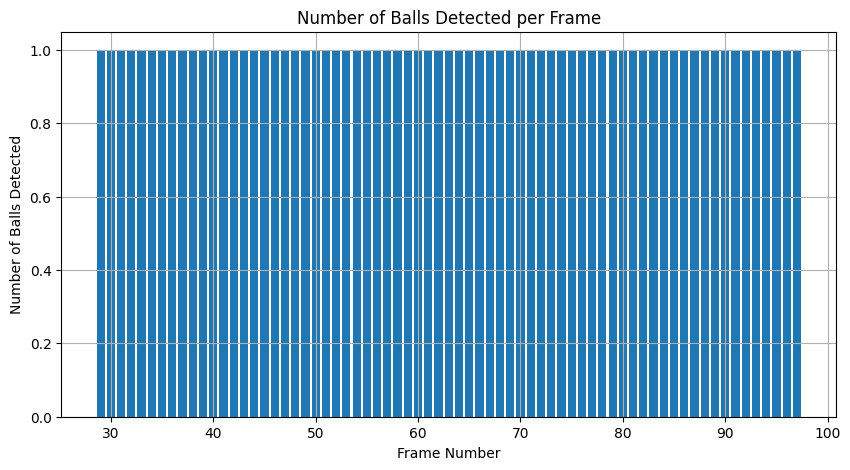

In [8]:
from collections import defaultdict

import matplotlib.pyplot as plt
def plot_balls_over_frames(tracked_data):
    # Filter data for sports balls (class 32)
    balls = [d for d in tracked_data if d['class'] == 32]

    # Count number of balls per frame
    ball_counts = defaultdict(int)
    for ball in balls:
        ball_counts[ball['frame']] += 1

    # Plot number of balls per frame
    frames = sorted(ball_counts.keys())
    counts = [ball_counts[f] for f in frames]
    plt.figure(figsize=(10, 5))
    plt.bar(frames, counts)
    plt.xlabel('Frame Number')
    plt.ylabel('Number of Balls Detected')
    plt.title('Number of Balls Detected per Frame')
    plt.grid(True)
    plt.show()

plot_balls_over_frames(tracked_data)

Although balls are lying in the background they are not identified as such. On one hand this is good, as we are only tracking the ball that is of relevance, at the same time, we most likely will have to track the ball for longer time. How can be make sure, that the ball is tracked for a longer time?

In [9]:
# Updated YOLO tracking function with changeable confidence threshold for the ball class
def yolo_Track_Extended(video_path, ball_conf_threshold=0.5):
    # Load YOLO model with tracking enabled
    model = YOLO("yolov8n.pt")
    
    cap = cv.VideoCapture(video_path)
    no_Frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    print('Total number of frames is', no_Frames)
    
    tracked_objects = []  # List to store tracked objects
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print('No frames grabbed!')
            break
        
        frame_count += 1
        
        # Process frame with YOLOv8 tracking, only for classes 0 (person) and 32 (sports ball)
        results = model.track(frame, classes=[0, 32], persist=True)
        
        if results[0].boxes is not None:
            for box in results[0].boxes:
                obj_id = int(box.id.item()) if box.id is not None else None
                bbox = box.xyxy[0].tolist()  # [x1, y1, x2, y2]
                cls = int(box.cls.item())
                conf = box.conf.item()
                
                # Skip balls with confidence below the threshold
                if cls == 32 and conf < ball_conf_threshold:
                    continue
                
                tracked_objects.append({
                    'frame': frame_count,
                    'id': obj_id,
                    'class': cls,
                    'bbox': bbox,
                    'confidence': conf
                })
        
        # Optional: Display the frame (comment out if not needed)
        frame_ = results[0].plot()
        cv.imshow('Result YOLO frame', frame_)
        
        k = cv.waitKey(30) & 0xff
        if k == 27:
            break
    
    cap.release()
    cv.destroyAllWindows()
    
    return tracked_objects

# Call the extended function with a higher confidence threshold for balls
tracked_data=yolo_Track_Extended(video_path=path_Video, ball_conf_threshold=0.005)

Total number of frames is 209

0: 512x640 1 person, 20.1ms
Speed: 1.0ms preprocess, 20.1ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 18.1ms
Speed: 0.8ms preprocess, 18.1ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 18.9ms
Speed: 0.8ms preprocess, 18.9ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 21.2ms
Speed: 0.7ms preprocess, 21.2ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 18.7ms
Speed: 0.6ms preprocess, 18.7ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 21.4ms
Speed: 1.0ms preprocess, 21.4ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 22.1ms
Speed: 0.7ms preprocess, 22.1ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 21.6ms
Speed: 1.1ms preprocess, 21.6ms inference, 0.5ms postproces

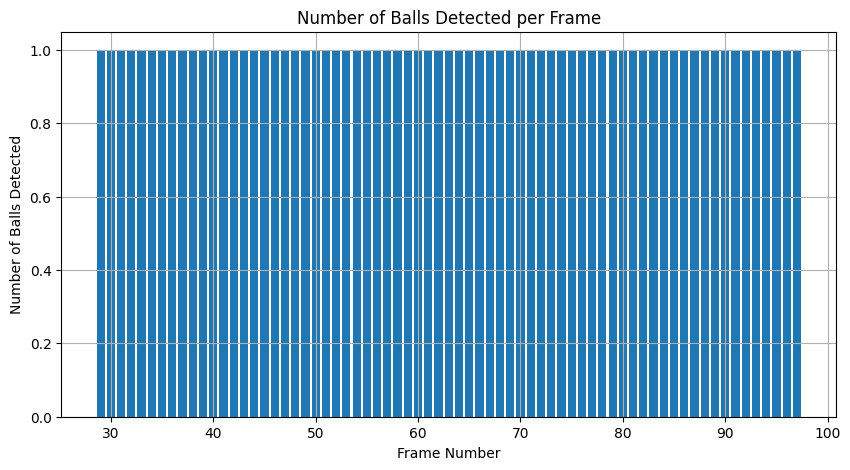

In [10]:
plot_balls_over_frames(tracked_data)

Well, jsut lowering the threshold did not seem to do the job. So what now? 

Occlusion is a very common problem in object tracking. Yolo has some other networks that work better with occlusion. So let's give Yolo26 a try:

There are a few models:
| Model	  | size (pixels) |	mAPval 50-95	| mAPval 50-95(e2e)	| Speed CPU ONNX (ms) |	Speed T4 TensorRT10 (ms)	| params (M) | FLOPs (B) |
| ------  | ------------- | --------------- | ----------------- |-------------------- |---------------------------- |----------- | --------- |
| YOLO26n |	640	          | 40.9            | 40.1              | 38.9 ± 0.7	      | 1.7 ± 0.0                   | 2.4        | 5.4       |
| YOLO26s |	640	          | 48.6	        | 47.8	            | 87.2 ± 0.9	      | 2.5 ± 0.0	                | 9.5	     | 20.7      |
| YOLO26m |	640	          | 53.1	        | 52.5	            | 220.0 ± 1.4	      | 4.7 ± 0.1	                | 20.4	     | 68.2      |
| YOLO26l |	640	          | 55.0	        | 54.4	            | 286.2 ± 2.0	      | 6.2 ± 0.2	                | 24.8	     | 86.4      |
| YOLO26x |	640	          | 57.5	        | 56.9	            | 25.8 ± 4.0	      | 11.8 ± 0.2	                | 55.7	     | 193.9     |

In [3]:
# Updated YOLO tracking function with changeable confidence threshold for the ball class
def yolo_Track_Extended(video_path, ball_conf_threshold=0.5):
    # Load YOLO model with tracking enabled
    model = YOLO("yolo26x.pt")
    
    cap = cv.VideoCapture(video_path)
    no_Frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    print('Total number of frames is', no_Frames)
    
    tracked_objects = []  # List to store tracked objects
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print('No frames grabbed!')
            break
        
        frame_count += 1
        
        # Process frame with YOLOv8 tracking, only for classes 0 (person) and 32 (sports ball)
        results = model.track(frame, classes=[0, 32], persist=True)
        
        if results[0].boxes is not None:
            for box in results[0].boxes:
                obj_id = int(box.id.item()) if box.id is not None else None
                bbox = box.xyxy[0].tolist()  # [x1, y1, x2, y2]
                cls = int(box.cls.item())
                conf = box.conf.item()
                
                # Skip balls with confidence below the threshold
                if cls == 32 and conf < ball_conf_threshold:
                    continue
                
                tracked_objects.append({
                    'frame': frame_count,
                    'id': obj_id,
                    'class': cls,
                    'bbox': bbox,
                    'confidence': conf
                })
        
        # Optional: Display the frame (comment out if not needed)
        frame_ = results[0].plot()
        cv.imshow('Result YOLO frame', frame_)
        
        k = cv.waitKey(30) & 0xff
        if k == 27:
            break
    
    cap.release()
    cv.destroyAllWindows()
    
    return tracked_objects

# Call the extended function with a higher confidence threshold for balls
tracked_data=yolo_Track_Extended(video_path=path_Video, ball_conf_threshold=0.005)

Total number of frames is 209

0: 512x640 1 person, 2 sports balls, 353.3ms
Speed: 1.2ms preprocess, 353.3ms inference, 0.3ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 321.4ms
Speed: 1.9ms preprocess, 321.4ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 338.9ms
Speed: 0.7ms preprocess, 338.9ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 322.9ms
Speed: 0.6ms preprocess, 322.9ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 345.3ms
Speed: 0.9ms preprocess, 345.3ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 378.0ms
Speed: 1.6ms preprocess, 378.0ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 295.6ms
Speed: 1.3ms preprocess, 295.6ms inference, 0.2ms postproces

Alright, so we can again update our list of good and bad:

Good:
* The athletes is detected quite well (high confidence)
* Only athletes and balls are identified

Bad:
* The ball is detected not well in parts of the video (occlusion), but it might be handleable
* Various balls in the background are detected as well

Let's try to identify the correct ball we want to track with the ID


First we need to plot the ball positions in a 2D-Plot

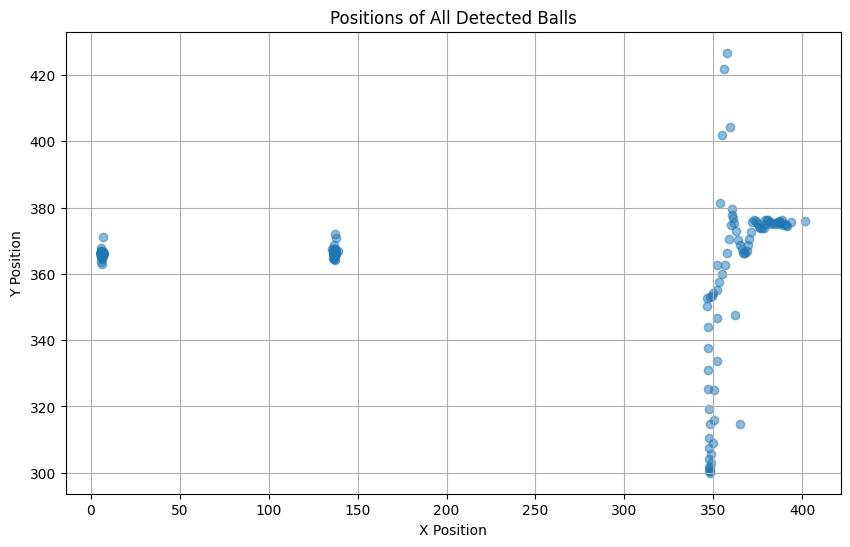

In [12]:
def plot_ball_positions(tracked_data):
    # Filter data for sports balls (class 32)
    balls = [d for d in tracked_data if d['class'] == 32]
    
    # Extract positions for all balls
    ball_positions = []
    for ball in balls:
        bbox = ball['bbox']
        x_center = (bbox[0] + bbox[2]) / 2
        y_center = (bbox[1] + bbox[3]) / 2
        ball_positions.append((x_center, y_center))
    
    # Separate x and y coordinates
    x_coords = [pos[0] for pos in ball_positions]
    y_coords = [pos[1] for pos in ball_positions]
    
    # Plot the positions
    plt.figure(figsize=(10, 6))
    plt.scatter(x_coords, y_coords, alpha=0.5)
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.title('Positions of All Detected Balls')
    plt.grid(True)
    plt.show()

# Call the function with the existing tracked_data
plot_ball_positions(tracked_data)

We see that the ball position of all balls that were detected vary. It seems like two of them are rather stationary, one of the is moving (probably our target ball). Can we see the Ball IDs along the plot somehow?

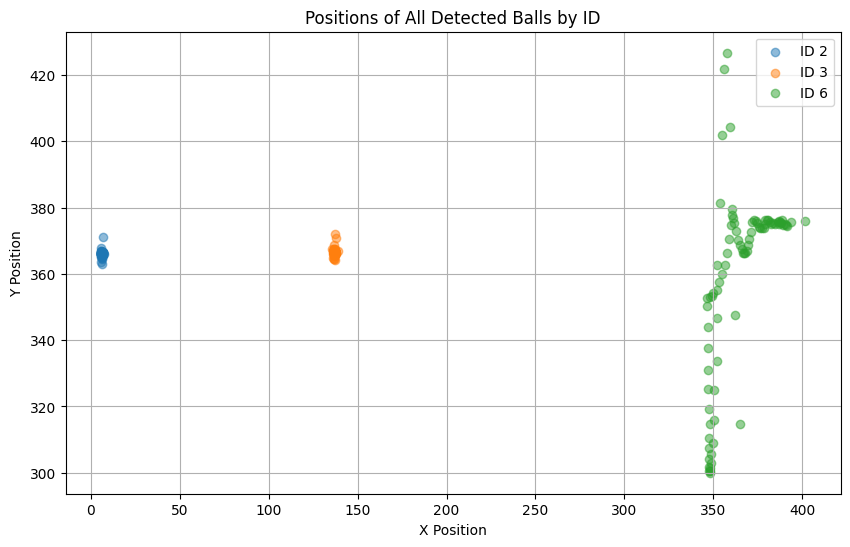

In [13]:
def plot_ball_positions(tracked_data):
    # Filter data for sports balls (class 32)
    balls = [d for d in tracked_data if d['class'] == 32]
    
    # Get unique IDs
    unique_ids = sorted(set(ball['id'] for ball in balls if ball['id'] is not None))
    
    # Use a colormap for colors
    colors = plt.cm.tab10.colors  # Or any other colormap
    
    plt.figure(figsize=(10, 6))
    
    for i, ball_id in enumerate(unique_ids):
        # Filter balls for this ID
        id_balls = [ball for ball in balls if ball['id'] == ball_id]
        
        # Extract positions
        x_coords = []
        y_coords = []
        for ball in id_balls:
            bbox = ball['bbox']
            x_center = (bbox[0] + bbox[2]) / 2
            y_center = (bbox[1] + bbox[3]) / 2
            x_coords.append(x_center)
            y_coords.append(y_center)
        
        # Plot with specific color
        plt.scatter(x_coords, y_coords, color=colors[i % len(colors)], label=f'ID {ball_id}', alpha=0.5)
    
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.title('Positions of All Detected Balls by ID')
    plt.legend()
    plt.grid(True)
    plt.show()

# Call the updated function with the existing tracked_data
plot_ball_positions(tracked_data)

OK, ID 6 seems to be the ball of interest. Lets see when we were able to track the ball and when not.

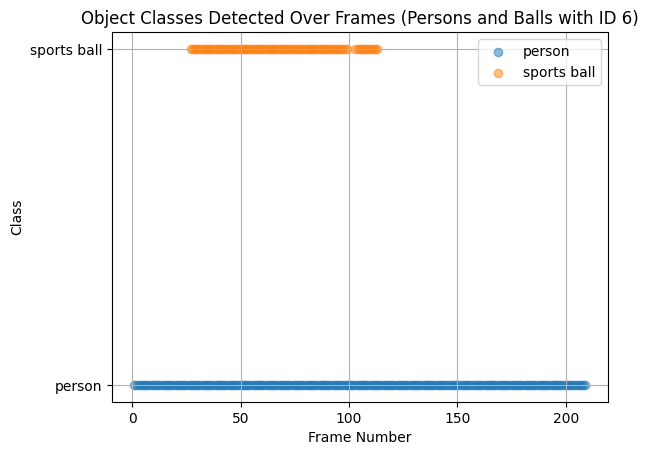

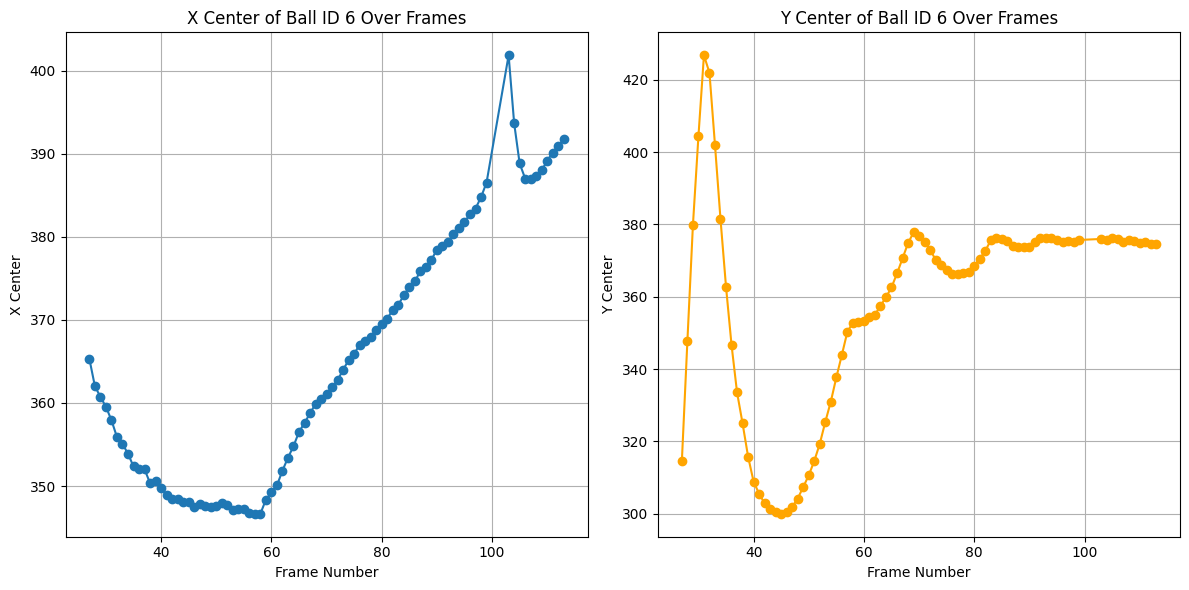

In [14]:
def plot_classes_over_frames(tracked_data):
        # Filter tracked_data to only include persons (class 0) and balls (class 32) with ID 6
        filtered_data = [d for d in tracked_data if d['class'] == 0 or (d['class'] == 32 and d.get('id') == 6)]
        
        # Plot the object classes over the frame number for the filtered data
        frames = [d['frame'] for d in filtered_data]
        classes = [d['class'] for d in filtered_data]

        # Define class names based on YOLOv8 COCO dataset
        class_names = {
            0: 'person',
            13: 'bench',
            32: 'sports ball'
        }

        # Distinguish between different classes by plotting each class with a different color
        unique_classes = sorted(set(classes))
        colors = plt.cm.tab10.colors  # Use a colormap for distinct colors

        for i, cls in enumerate(unique_classes):
            cls_frames = [f for f, c in zip(frames, classes) if c == cls]
            plt.scatter(cls_frames, [i] * len(cls_frames), color=colors[i % len(colors)], label=class_names.get(cls, f'Class {cls}'), alpha=0.5)

        plt.yticks(range(len(unique_classes)), [class_names.get(cls, f'Class {cls}') for cls in unique_classes])
        plt.legend()
        plt.xlabel('Frame Number')
        plt.ylabel('Class')
        plt.title('Object Classes Detected Over Frames (Persons and Balls with ID 6)')
        plt.grid(True)
        plt.show()

def plot_ball_trajectory(tracked_data, ball_id=6):
    # Filter data for sports balls with the specified ID
    balls_id = [d for d in tracked_data if d['class'] == 32 and d.get('id') == ball_id]
    
    # Extract frames, x_centers, y_centers
    frames = [ball['frame'] for ball in balls_id]
    x_centers = [(ball['bbox'][0] + ball['bbox'][2]) / 2 for ball in balls_id]
    y_centers = [(ball['bbox'][1] + ball['bbox'][3]) / 2 for ball in balls_id]
    
    # Plot x and y centers over frames
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(frames, x_centers, marker='o')
    plt.xlabel('Frame Number')
    plt.ylabel('X Center')
    plt.title(f'X Center of Ball ID {ball_id} Over Frames')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(frames, y_centers, marker='o', color='orange')
    plt.xlabel('Frame Number')
    plt.ylabel('Y Center')
    plt.title(f'Y Center of Ball ID {ball_id} Over Frames')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Call the function to plot classes over frames for balls with ID 6
plot_classes_over_frames(tracked_data)

# Call the function with the existing tracked_data
plot_ball_trajectory(tracked_data)

OK, now we see the ball longer, but after the shot was taken by the athlete we are not able to detect it again. Still, occlusion is a problem, but we can try to solve it by saying, if we miss the detection for a few frames, we can interpolate the bounding boxes inbetween. How do we dso that?

In [15]:
def interpolate_ball_tracking(tracked_data, ball_id=6, ball_class=32):
    # Filter data for the specific ball (class 32, id 6)
    ball_data = [d for d in tracked_data if d['class'] == ball_class and d.get('id') == ball_id]
    
    if not ball_data:
        return tracked_data  # No data to interpolate
    
    # Sort by frame
    ball_data.sort(key=lambda x: x['frame'])
    
    # Find gaps
    interpolated_data = []
    for i in range(len(ball_data) - 1):
        current = ball_data[i]
        next_ = ball_data[i + 1]
        gap_frames = next_['frame'] - current['frame'] - 1
        
        if gap_frames > 0:
            # Interpolate bbox linearly
            start_bbox = current['bbox']
            end_bbox = next_['bbox']
            for j in range(1, gap_frames + 1):
                t = j / (gap_frames + 1)
                interp_bbox = [
                    start_bbox[0] + t * (end_bbox[0] - start_bbox[0]),
                    start_bbox[1] + t * (end_bbox[1] - start_bbox[1]),
                    start_bbox[2] + t * (end_bbox[2] - start_bbox[2]),
                    start_bbox[3] + t * (end_bbox[3] - start_bbox[3])
                ]
                interpolated_data.append({
                    'frame': current['frame'] + j,
                    'id': ball_id,
                    'class': ball_class,
                    'bbox': interp_bbox,
                    'confidence': (current['confidence'] + next_['confidence']) / 2  # Average confidence
                })
    
    # Add interpolated data to tracked_data
    tracked_data.extend(interpolated_data)
    # Sort the entire list by frame
    tracked_data.sort(key=lambda x: x['frame'])
    
    return tracked_data

# Call the function to interpolate missing ball tracking
tracked_data = interpolate_ball_tracking(tracked_data)

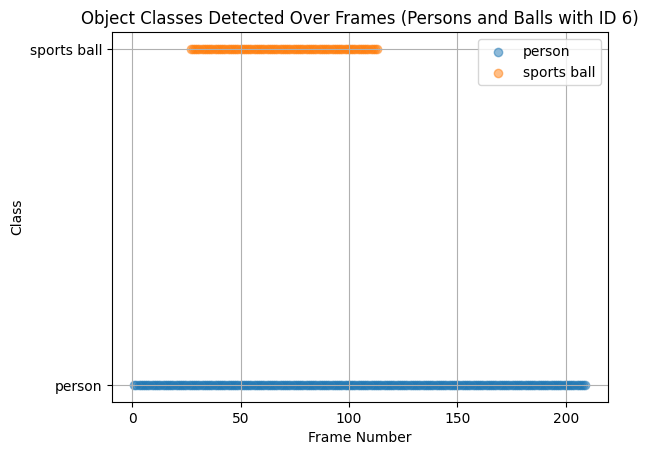

In [16]:
plot_classes_over_frames(tracked_data)

As it seems, we have now tracked an occluded object, but how is the position of the bounding box now? Does it work?

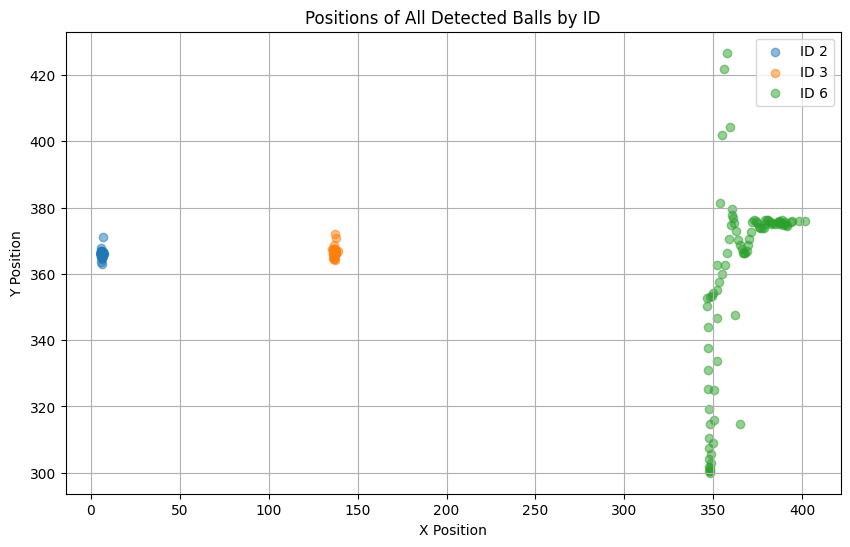

In [17]:
plot_ball_positions(tracked_data)

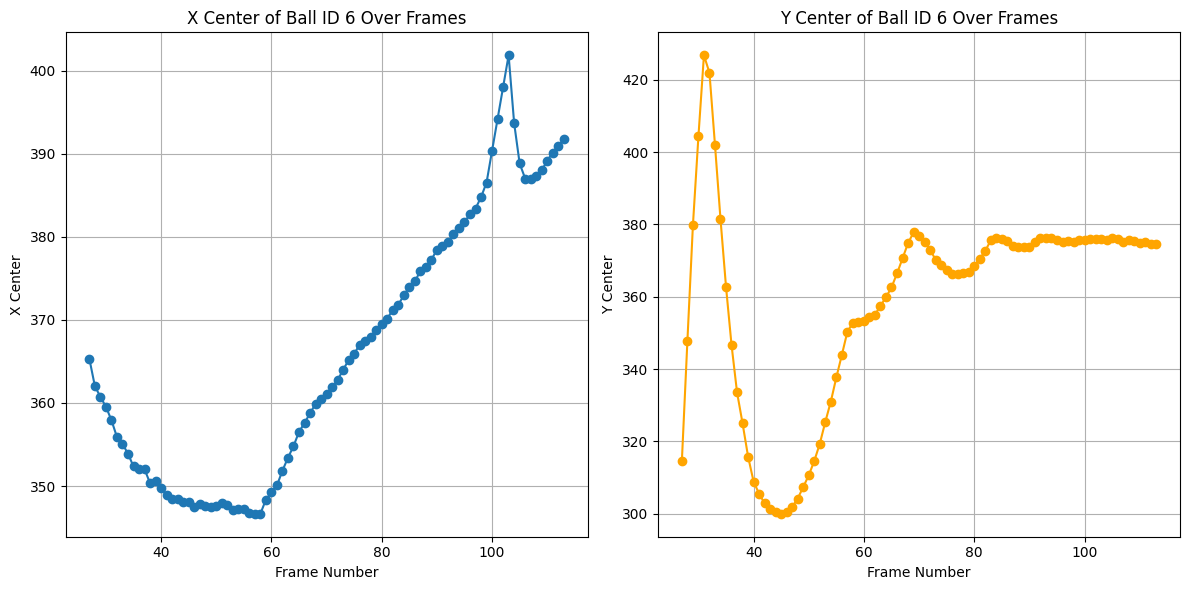

In [ ]:
def plot_ball_trajectory(tracked_data, ball_id=6):
    # Filter data for sports balls with the specified ID
    balls_id = [d for d in tracked_data if d['class'] == 32 and d.get('id') == ball_id]
    
    # Extract frames, x_centers, y_centers
    frames = [ball['frame'] for ball in balls_id]
    x_centers = [(ball['bbox'][0] + ball['bbox'][2]) / 2 for ball in balls_id]
    y_centers = [(ball['bbox'][1] + ball['bbox'][3]) / 2 for ball in balls_id]
    
    # Plot x and y centers over frames
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(frames, x_centers, marker='o')
    plt.xlabel('Frame Number')
    plt.ylabel('X Center')
    plt.title(f'X Center of Ball ID {ball_id} Over Frames')
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(frames, y_centers, marker='o', color='orange')
    plt.xlabel('Frame Number')
    plt.ylabel('Y Center')
    plt.title(f'Y Center of Ball ID {ball_id} Over Frames')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


# Call the function with the existing tracked_data
plot_ball_trajectory(tracked_data)


Now we have also the missing bounding box information for the few frames from 100 on. We can Update the good and bad list now once more:

Good:
* The athletes is detected quite well (high confidence)
* Only athletes and balls are identified
* Various balls in the background are detected as well, but we can ignore them with the ID
* The ball is detected not well in parts of the video (occlusion), but it was handable

Bad:
* We could not detect the ball after the shot was taken
* We only optimized for one video. We have no idea if it works for several 1000 Videos

#### TASKS:
* Try to track also the fast moving ball
* Try to use other things than Yolo
* Try to scale it now for a sereis of videos.